In [ ]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
digits = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/digits.csv")
digits.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#identifying target and features

labels = digits['label']
digits = np.array(digits.drop('label', axis=1)).astype('float')
digits.shape, labels.shape

((42000, 784), (42000,))

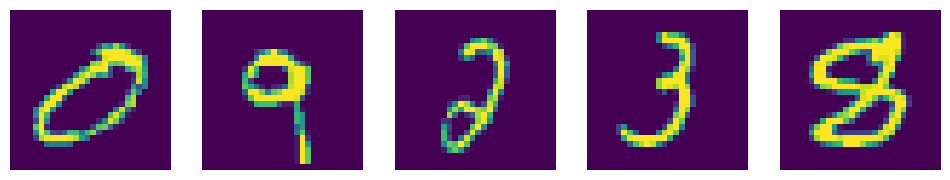

In [ ]:
plt.figure(figsize = (12,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(random.choice(digits).reshape(28,28))
    plt.axis("off")

In [ ]:
from sklearn.model_selection import train_test_split

digits=digits/255.0

#split

X_train, X_test, y_train, y_test = train_test_split(digits,labels, test_size = 0.3, random_state = 42)

X_train.shape, X_test.shape

((29400, 784), (12600, 784))

In [ ]:
model = MLPClassifier().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"accuracy {accuracy_score(y_pred, y_test)}")

Using MLPClassifier with the default parameter values gives an accuracy of 0.9723015873015873


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1205
           1       0.99      0.98      0.99      1398
           2       0.97      0.97      0.97      1291
           3       0.97      0.96      0.96      1360
           4       0.97      0.98      0.97      1214
           5       0.96      0.96      0.96      1086
           6       0.98      0.98      0.98      1253
           7       0.97      0.98      0.98      1355
           8       0.97      0.97      0.97      1207
           9       0.96      0.96      0.96      1231

    accuracy                           0.97     12600
   macro avg       0.97      0.97      0.97     12600
weighted avg       0.97      0.97      0.97     12600



In [ ]:
model_1 = RandomizedSearchCV(
    MLPClassifier(),
    {
        'hidden_layer_sizes': [50, 100, 200],
        'alpha': [0.001, 0.01, 0.1],
        'max_iter': [200, 500, 800],
        'learning_rate_init': [1e-4, 1e-3, 1e-2, 1e-1]
    },
    cv=5
)
model_1.fit(X_train[:3000], y_train[:3000])

bestmodel = clf.best_estimator_
print(clf.best_params_)

In [ ]:
print("Accuracy:", accuracy_score(y_test, bestmodel.predict(X_test)))

The accuracy score of the best model is 0.932063492063492



The accuracy score of the best model is 0.932063492063492



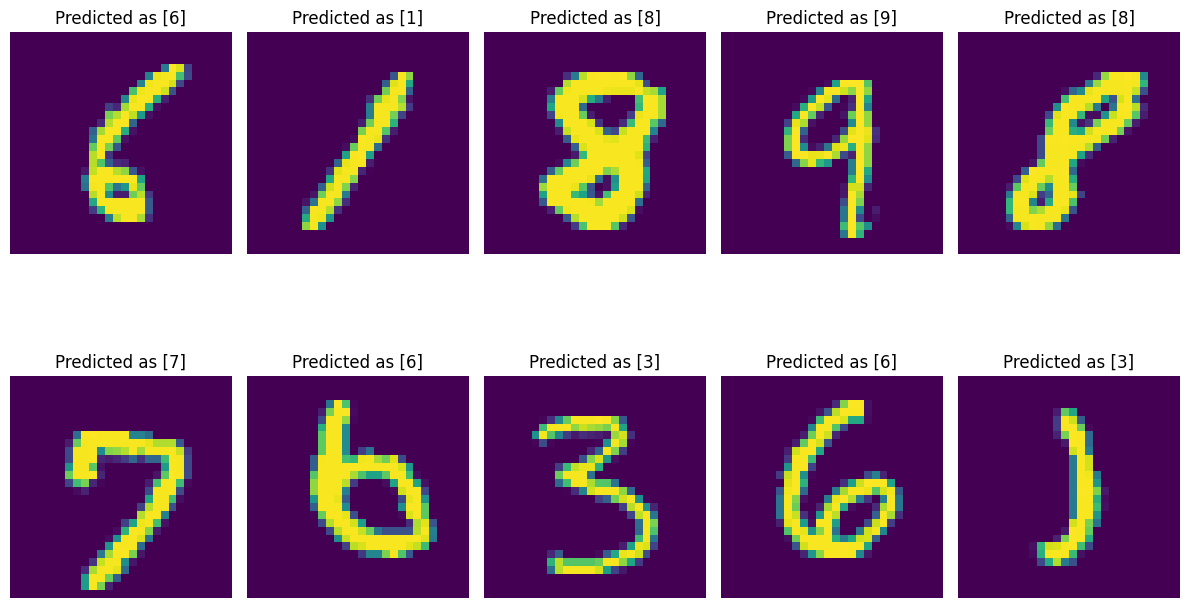

In [ ]:
from sklearn.metrics import accuracy_score

# accuracy
print("Accuracy:", accuracy_score(y_test, bestmodel.predict(X_test)))

# visualization
plt.figure(figsize=(12,8))
for i, sample in enumerate(X_test[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample.reshape(28,28))
    plt.title(f"Pred: {bestmodel.predict(sample.reshape(1,-1))[0]}")
    plt.axis("off")

plt.tight_layout()